## Predicting HDB Resale Flat Prices

The dataset contains historical data from JANUARY 2017 to MARCH 2026.

In [80]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = pd.read_csv("resale_flat_prices.csv")

In [5]:
data

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
226466,2026-02,YISHUN,EXECUTIVE,292,YISHUN ST 22,01 TO 03,165.0,Apartment,1992,65 years 05 months,940000.0
226467,2026-02,YISHUN,EXECUTIVE,258,YISHUN ST 22,01 TO 03,148.0,Maisonette,1985,58 years 04 months,800000.0
226468,2026-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,60 years 09 months,825000.0
226469,2026-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,04 TO 06,146.0,Maisonette,1987,60 years 08 months,788000.0


In [6]:
data.info() # Check for missing data - no missing data found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226471 entries, 0 to 226470
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226471 non-null  object 
 1   town                 226471 non-null  object 
 2   flat_type            226471 non-null  object 
 3   block                226471 non-null  object 
 4   street_name          226471 non-null  object 
 5   storey_range         226471 non-null  object 
 6   floor_area_sqm       226471 non-null  float64
 7   flat_model           226471 non-null  object 
 8   lease_commence_date  226471 non-null  int64  
 9   remaining_lease      226471 non-null  object 
 10  resale_price         226471 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.0+ MB


In [7]:
# Getting HDB age using a function 

def get_hdb_age(lease):
    lease = str(lease).lower().strip()
    lease = lease.replace("years", "").replace("year","")
    lease = lease.replace("months","").replace("month","")

    parts = lease.split()

    years = 0
    months = 0 

    if len(parts) == 2:
        years = int(parts[0])
        months = int(parts[1])
    elif len(parts) == 1:
        years = int(parts[0])

    if months >=6:                   # Rounding up of the age to a whole number
        lease_left = years + 1

    else:
        lease_left = years 

    return 99 - lease_left

data["hdb_age"] = data["remaining_lease"].apply(get_hdb_age)

data["hdb_age"]

0         38
1         38
2         37
3         37
4         37
          ..
226466    34
226467    41
226468    38
226469    38
226470    38
Name: hdb_age, Length: 226471, dtype: int64

In [8]:
data.info

<bound method DataFrame.info of           month        town  flat_type block        street_name storey_range  \
0       2017-01  ANG MO KIO     2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1       2017-01  ANG MO KIO     3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2       2017-01  ANG MO KIO     3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3       2017-01  ANG MO KIO     3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4       2017-01  ANG MO KIO     3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   
...         ...         ...        ...   ...                ...          ...   
226466  2026-02      YISHUN  EXECUTIVE   292       YISHUN ST 22     01 TO 03   
226467  2026-02      YISHUN  EXECUTIVE   258       YISHUN ST 22     01 TO 03   
226468  2026-01      YISHUN  EXECUTIVE   643       YISHUN ST 61     10 TO 12   
226469  2026-01      YISHUN  EXECUTIVE   643       YISHUN ST 61     04 TO 06   
226470  2026-02      YISHUN  EXECUTIVE   611       YISHUN ST 61     04 TO 06   

       

In [9]:
data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,hdb_age
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,38
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,38
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,37
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,37
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,37


In [10]:
sorted(data['flat_type'].unique())

['1 ROOM',
 '2 ROOM',
 '3 ROOM',
 '4 ROOM',
 '5 ROOM',
 'EXECUTIVE',
 'MULTI-GENERATION']

In [11]:
sorted(data['flat_model'].unique())

['2-room',
 '3Gen',
 'Adjoined flat',
 'Apartment',
 'DBSS',
 'Improved',
 'Improved-Maisonette',
 'Maisonette',
 'Model A',
 'Model A-Maisonette',
 'Model A2',
 'Multi Generation',
 'New Generation',
 'Premium Apartment',
 'Premium Apartment Loft',
 'Premium Maisonette',
 'Simplified',
 'Standard',
 'Terrace',
 'Type S1',
 'Type S2']

In [12]:
sorted(data['storey_range'].unique())

['01 TO 03',
 '04 TO 06',
 '07 TO 09',
 '10 TO 12',
 '13 TO 15',
 '16 TO 18',
 '19 TO 21',
 '22 TO 24',
 '25 TO 27',
 '28 TO 30',
 '31 TO 33',
 '34 TO 36',
 '37 TO 39',
 '40 TO 42',
 '43 TO 45',
 '46 TO 48',
 '49 TO 51']

In [13]:
sorted(data['town'].unique())

['ANG MO KIO',
 'BEDOK',
 'BISHAN',
 'BUKIT BATOK',
 'BUKIT MERAH',
 'BUKIT PANJANG',
 'BUKIT TIMAH',
 'CENTRAL AREA',
 'CHOA CHU KANG',
 'CLEMENTI',
 'GEYLANG',
 'HOUGANG',
 'JURONG EAST',
 'JURONG WEST',
 'KALLANG/WHAMPOA',
 'MARINE PARADE',
 'PASIR RIS',
 'PUNGGOL',
 'QUEENSTOWN',
 'SEMBAWANG',
 'SENGKANG',
 'SERANGOON',
 'TAMPINES',
 'TOA PAYOH',
 'WOODLANDS',
 'YISHUN']

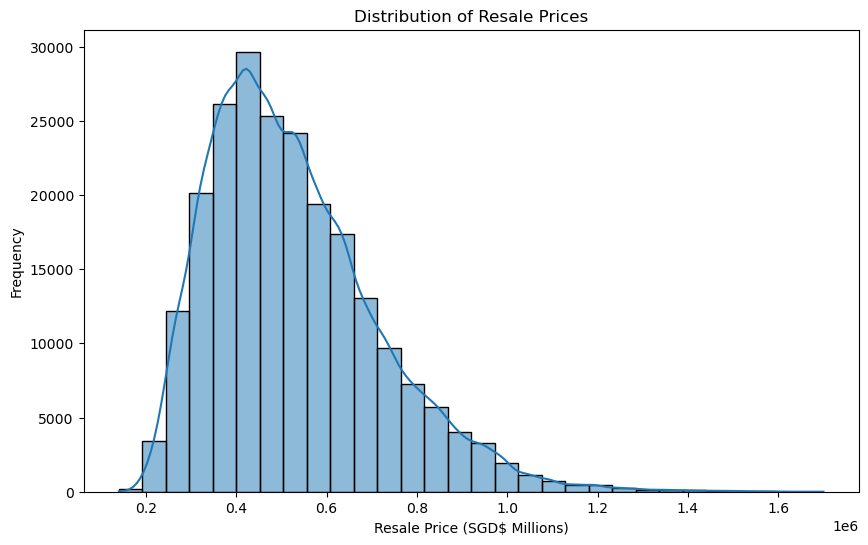

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data['resale_price'], bins = 30, kde = True)
plt.title('Distribution of Resale Prices')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Frequency')
plt.show()

### Resale Price Distribution for Resale HDB Flats (Jan 2017 to March 2026)

The histogram illustrates the frequency distribution of resale prices for flats from January 2017 to March 2026. Most resale prices cluster between SGD 300,000 and SGD 500,000, where a high concentration of flats are sold in this range of price. Distribution is a right-skewed pattern, indicating that fewer flats are being sold at higher price range, of more than SGD $600,000. The short tail on the lower end implies that there is a minimum threshold of about SGD200,000 where fewer flats are being sold at a price range closer to the threshold. The distribution indicates that there is a high demand or there is a market for mid-priced flats. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_89780/1494950141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'flat_type', y = 'resale_price', data=data, palette = 'coolwarm')


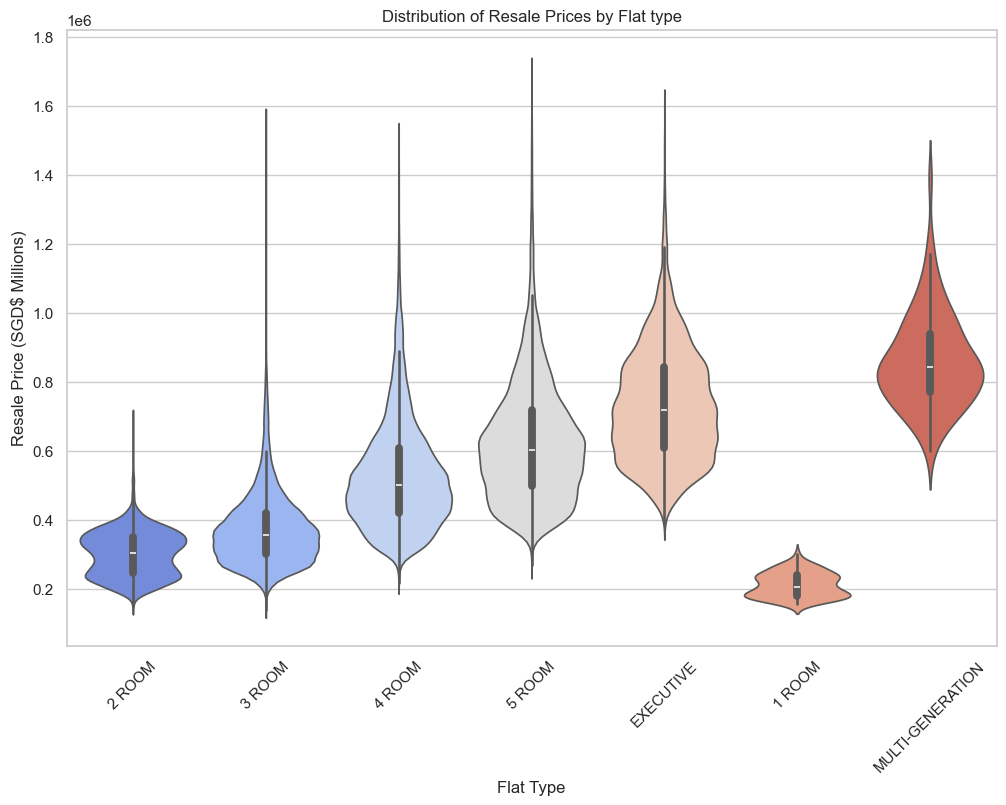

In [16]:
sns.set(style = "whitegrid")

plt.figure(figsize = (12,8)) 
sns.violinplot(x = 'flat_type', y = 'resale_price', data=data, palette = 'coolwarm')
plt.title('Distribution of Resale Prices by Flat type')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.xlabel('Flat Type')
plt.xticks(rotation = 45) 

plt.show()

### Distribution of Resale Price by Flat Type
The violin plot illustrates the distribution of resale prices segmented by flat types. It shows that 5 Room flats have a wider spread of prices while 1 Room flats have the smallest spread of prices. Multi-generation flats have the highest median prices compared to the other flat types. 2 Room and 1 Room flats have 2 distinct bulge in the violin plot.

This distribution therefore implies that 5 Room flats prices are more dispersed, suggesting that there may be factors that create this price variation while 1 Room flats have smaller price distribution which indicates stable and predictable price range. Multi-generation flats tend to be sold at higher resale price with a relatively even distributed around a central value, as seen from the smooth bell-shaped. Additionally, 2 Room and 1 Room flats may have distinct sub-markets within the same flat type which may indicate possible factors that drive such price range.

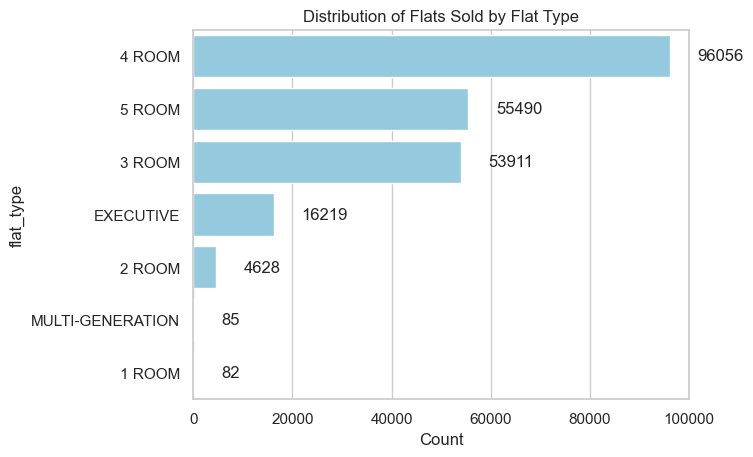

In [18]:
ax = sns.barplot(y = data['flat_type'].value_counts().index, x = data['flat_type'].value_counts().values, color = 'skyblue')
plt.title("Distribution of Flats Sold by Flat Type")
ax.bar_label(ax.containers[0], label_type = 'edge', padding = 20)
ax.set_xlim(0,100000)
plt.xlabel('Count')
plt.show()

### Distribution of Flats Sold by Flat Type

The bar chart illustrates the frequency of flats sold by flat type. 4 Room flats are the most common, followed by 5 Room flats and 3 Room flats. Multi-generation and 1 Room flats are scarce.

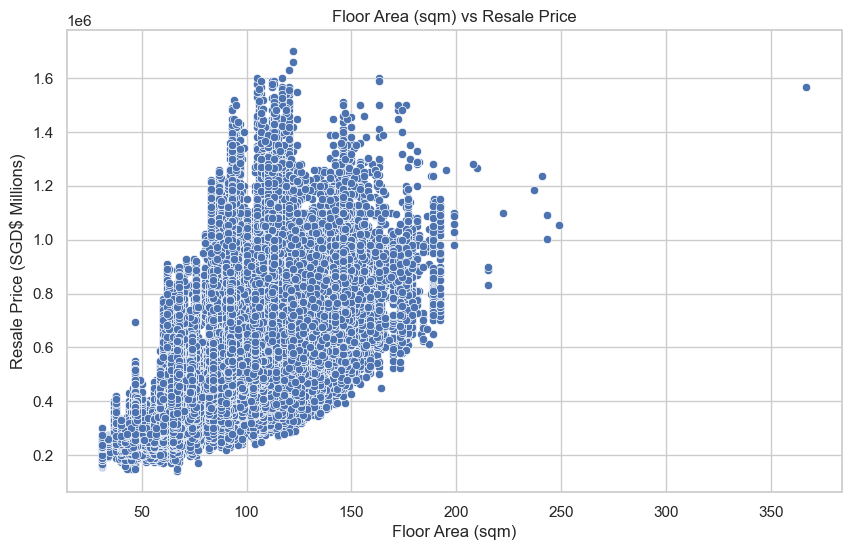

In [20]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'floor_area_sqm', y = 'resale_price', data = data)
plt.title('Floor Area (sqm) vs Resale Price')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()



### Relationship between Floor Area and Resale Price

The scatter plot illustrates the relationship between Floor Area(sqm) and Resale Prices. There is a upward trend of larger flats (sqm) will fetch a higher resale prices. However, the wide spread of resale price for flats with similar size (sqm) indicates that there are other factors that influence resale prices. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_89780/4136127080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = 'storey_range', y = 'resale_price', order = storey_order, palette = 'coolwarm')


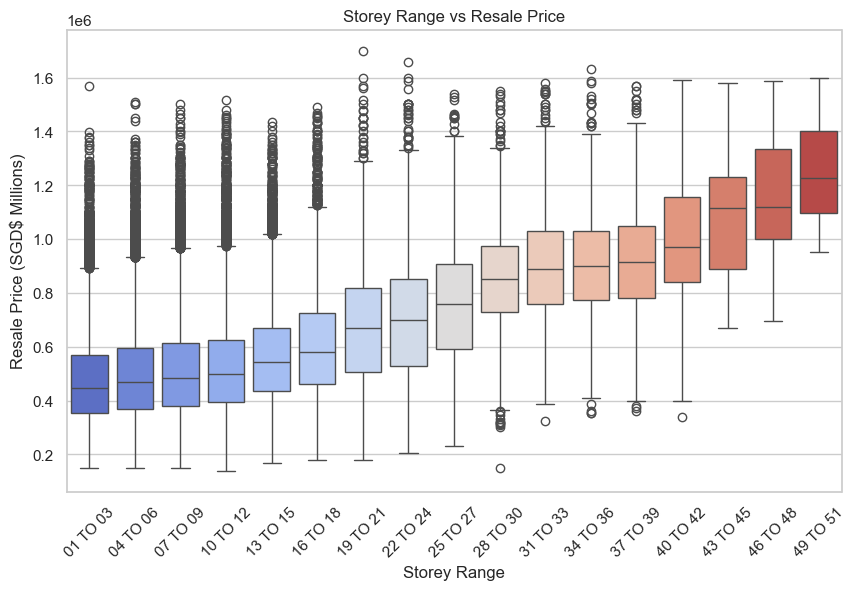

In [22]:
storey_order = sorted(data['storey_range'].dropna().unique())

plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = 'storey_range', y = 'resale_price', order = storey_order, palette = 'coolwarm')
plt.xticks(rotation = 45)
plt.title('Storey Range vs Resale Price')
plt.xlabel('Storey Range')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()

### Distribution of Resale Price by Storey Range

The box plot depicts an upward trend in the median resale price across the higher storey ranges, suggesting that flats located on higher floors tend to be sold at higher resale price range. This indicates that storey level may be a contributing factor to housing value where buyers are willing to pay a premium price for units at higher floors. 

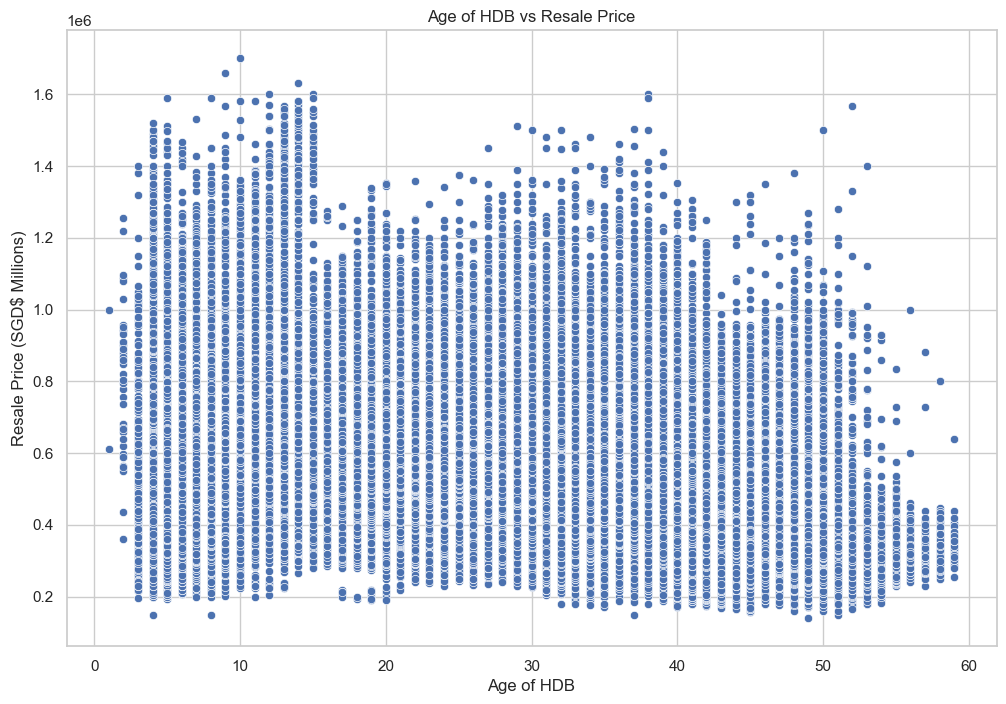

In [24]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = 'hdb_age', y = 'resale_price', data = data)
plt.title('Age of HDB vs Resale Price')
plt.xlabel('Age of HDB')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()

### Relationship between Age of HDB and Resale Price

The scatter plot illustrates a gradual downward trend between the Age of HDB and Resale price, indicating older flats tend to have lower resale prices. This corresponds to buyers unwilling to pay much for older flats with shorter remaining lease periods.

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_89780/800047624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = 'town', x = 'resale_price', order = town_order, palette = 'coolwarm')


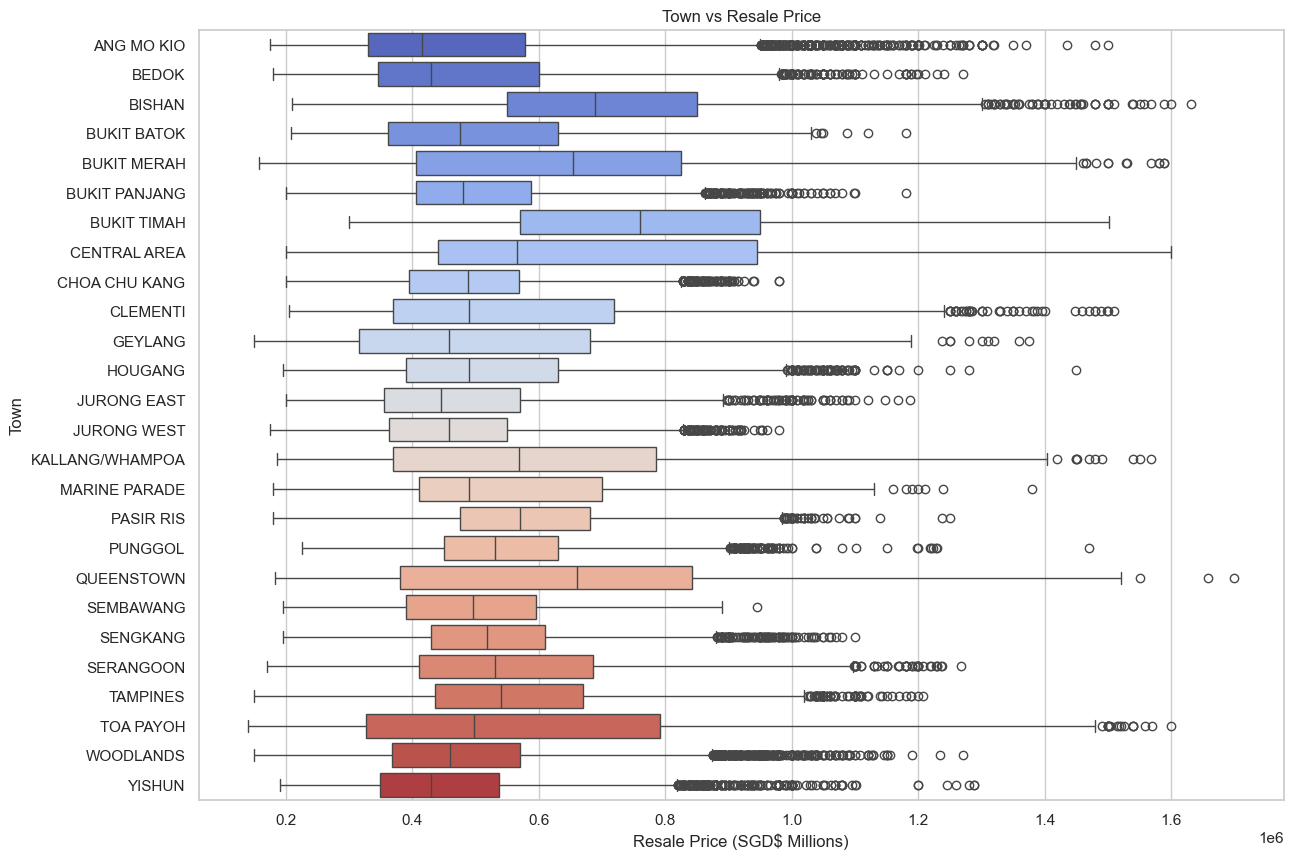

In [26]:
town_order = sorted(data['town'].dropna().unique())

plt.figure(figsize = (14,10))
sns.boxplot(data = data, y = 'town', x = 'resale_price', order = town_order, palette = 'coolwarm')
plt.title('Town vs Resale Price')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Town')
plt.show()

### Distribution of Resale Price by Town

The box plot depicts some towns have a higher median resale price, such as Bukit Timah, Central Area, Bishan, Queenstown and Kallang / Whampoa. On the other hand, towns such as Ang Mo Kio, Yishun and Woodlands have more affordable price range with tighter price distribution, suggesting that there is a high demand for lower price range flats. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_89780/3687982398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = 'flat_model', x = 'resale_price', order = flat_model_order, palette = 'coolwarm')


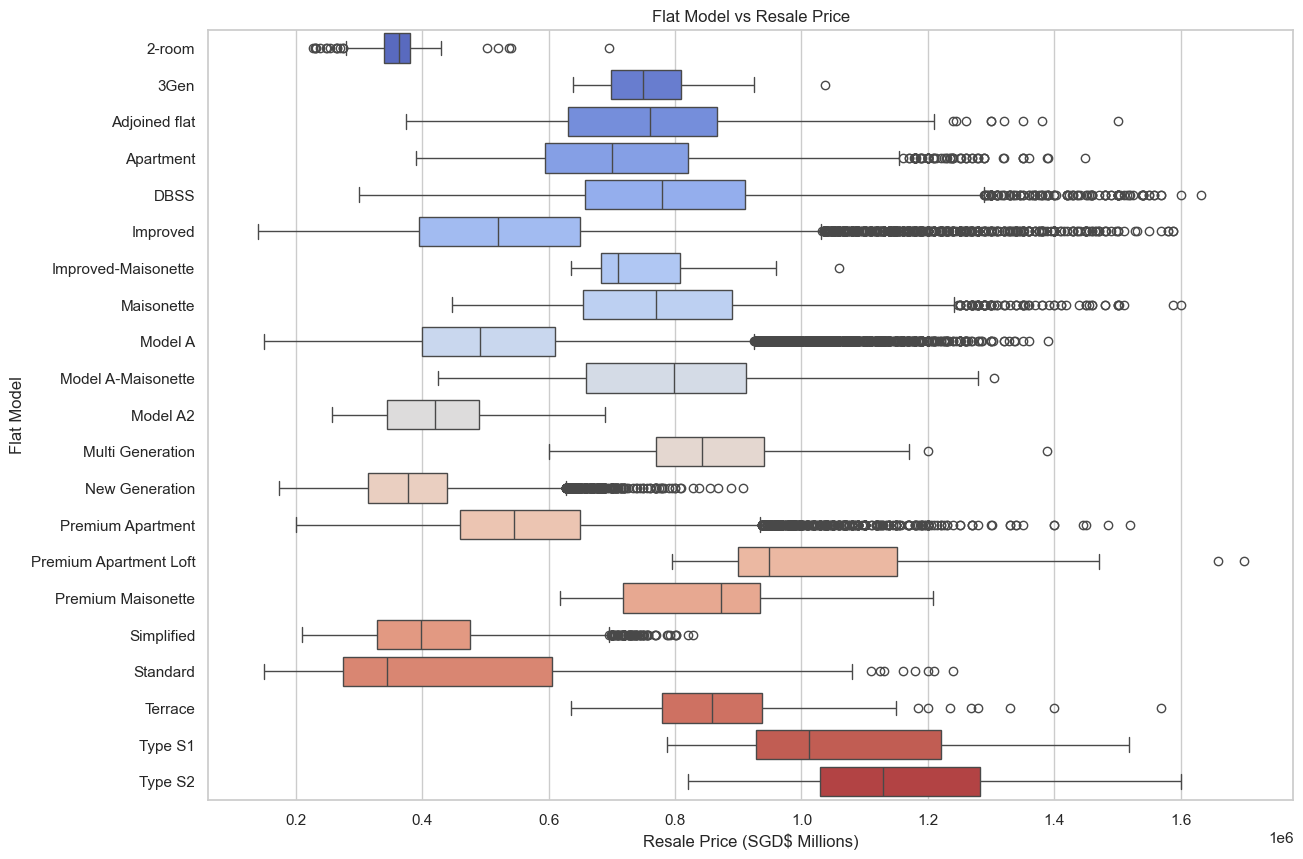

In [28]:
flat_model_order = sorted(data['flat_model'].dropna().unique())

plt.figure(figsize = (14,10))
sns.boxplot(data = data, y = 'flat_model', x = 'resale_price', order = flat_model_order, palette = 'coolwarm')
plt.title('Flat Model vs Resale Price')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Flat Model')
plt.show()

### Distribution of Resale Price by Flat Model

The box plot depicts the different flat model and its median resale price. 

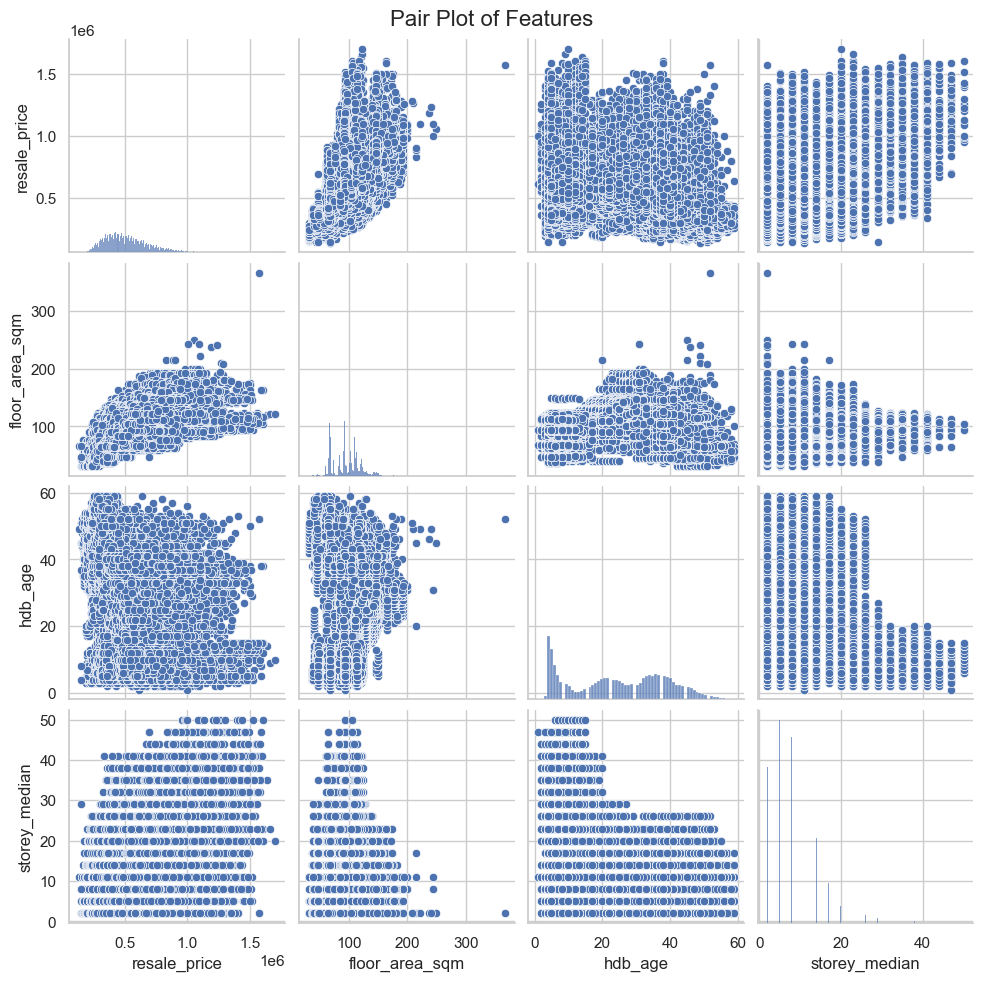

In [30]:
columns_to_plot = ['resale_price', 'floor_area_sqm', 'hdb_age', 'storey_range']

def storey_midpoint(x): 
    low, high = x.split(' TO ' ) 
    return (int(low) + int(high)) / 2

data['storey_median'] = data['storey_range'].apply(storey_midpoint)

columns_to_plot[3] = 'storey_median'

sns.pairplot(data[columns_to_plot].dropna())
plt.suptitle('Pair Plot of Features', size = 16)
plt.subplots_adjust(top=0.95) 
plt.show()

### Pairplot 
* illustrates the pair-wise relationship between the features.

#### Features used: 
* __Resale Price:__ Resale price of flat.
* __HDB Age:__ Age of HDB flat derived from remaining lease. 
* __Median Storey Range:__ The average or median storey level of the flat. 
* __Floor Area:__ Total floor area of flat in square meters which gives us a sense of the size of flat.


#### Observations from graphs:
* __Resale Price vs Floor Area:__ The larger the flats are based on square meters, the higher the resale price of the flat.
* __Resale Price vs HDB Age:__ There is weak negative relationship between HDB age and resale price where the younger/newer the flat is, the higher the price of the flat. However, due to the points being widely dispersed, there is a possibility of other redeeming features that explains the variation in resale price.
* __Resale Price vs Storey range (median):__ There is weak relationship between storey range and resale price

### Cluster Analysis (elbow method)

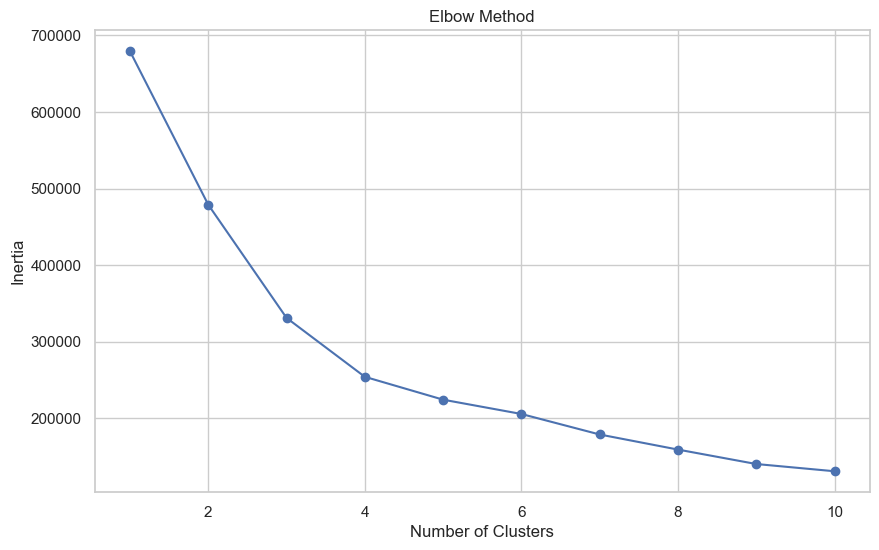

In [33]:
features = data[['hdb_age', 'floor_area_sqm', 'storey_median']]
features = StandardScaler().fit_transform(features)

inertia = [] 
for k in range (1,11): 
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize = (10,6))
plt.plot(range(1,11), inertia, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters') 
plt.ylabel('Inertia') 
plt.show()

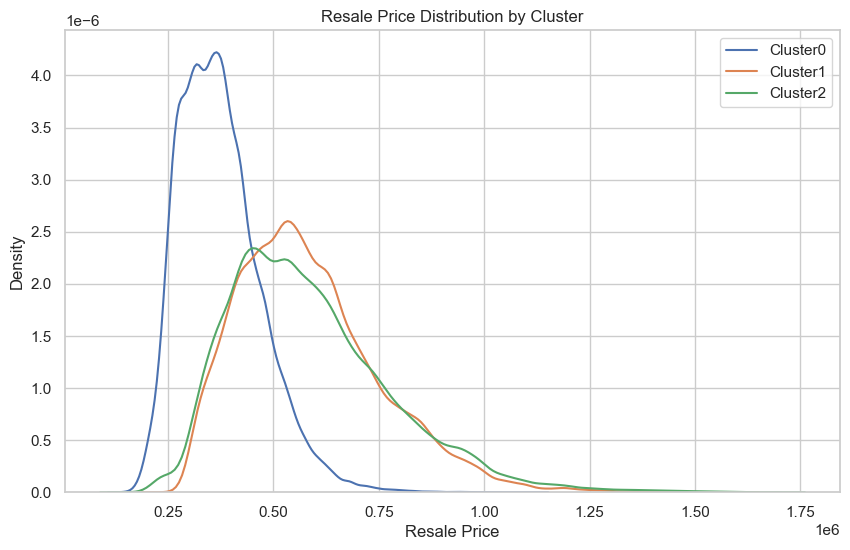

In [34]:
optimal_k = 3
kmeans = KMeans(n_clusters = optimal_k, random_state = 42) 
clusters = kmeans.fit_predict(features) 

data['Cluster'] = clusters 

plt.figure(figsize = (10,6))
for cluster in range(optimal_k): 
    cluster_data = data[data['Cluster'] == cluster]
    sns.kdeplot(cluster_data['resale_price'], label = f'Cluster{cluster}')
    
plt.title('Resale Price Distribution by Cluster')
plt.xlabel('Resale Price')
plt.ylabel('Density')
plt.legend()
plt.show()

### Cluster Analysis 

__Elbow Method Graph:__ Through the elbow method to determine the optimal number of clusters, the 'elbow' point suggests the most suitable number of clusters to use is 3. 

__Resale Price Distribution:__ The 3 clusters show different resale price distribution, suggesting that each cluster represents a distinct housing segment. Cluster 0 has a distribution that is more concentrated at the lower price range, indicating a more affordable segment. On the other hand, Cluster 1 and 2 shows a wider spread of resale prices, which suggests that there is greater variability within these 2 clusters.

In [110]:
data.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
hdb_age                  int64
storey_median          float64
Cluster                  int32
dtype: object

In [37]:
categorical_variables = data.select_dtypes(include=['object']).columns
encoded_data = pd.get_dummies(data, columns = categorical_variables, drop_first = True)

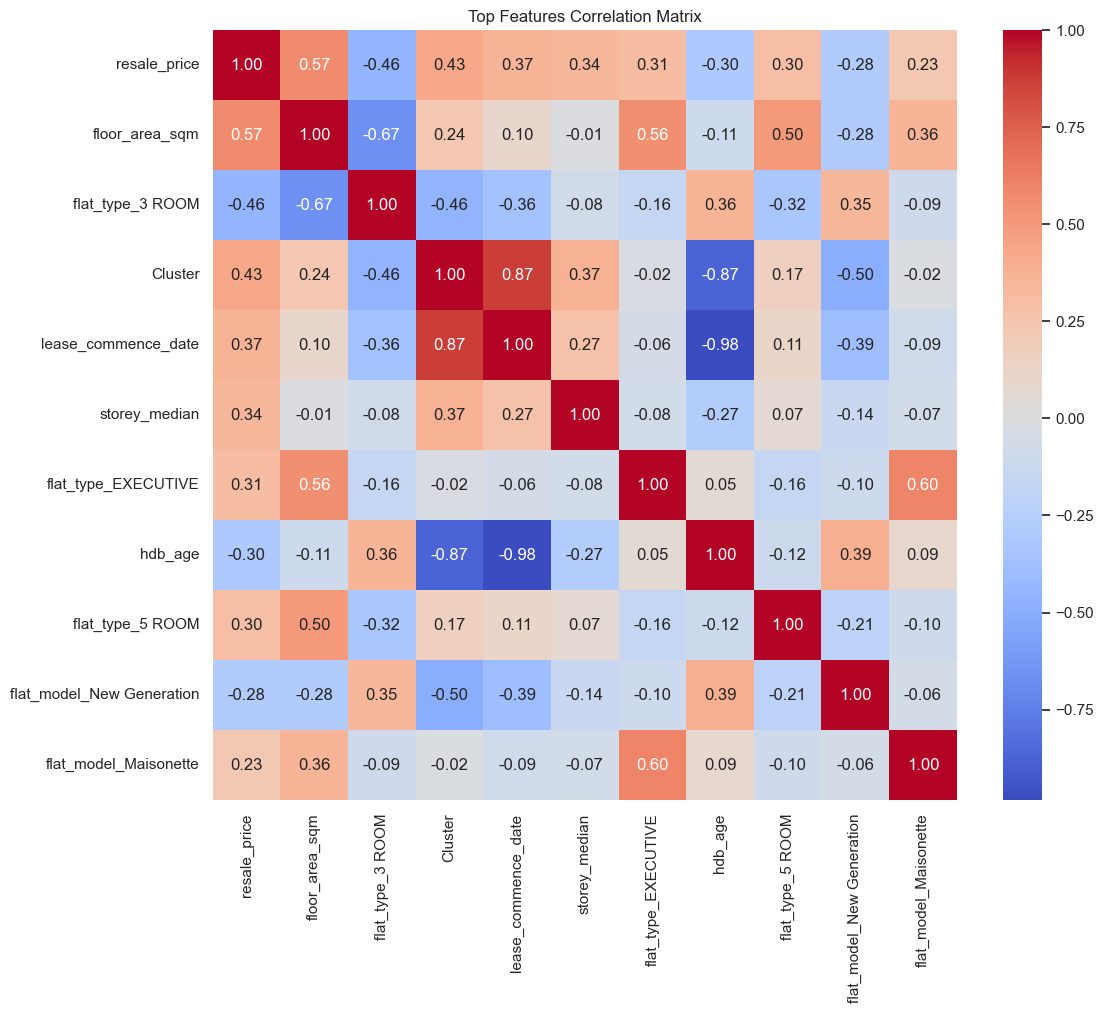

In [38]:
corr_matrix = encoded_data.corr()

top_features = corr_matrix['resale_price'].abs().sort_values(ascending=False).head(11).index

selected_corr_matrix = encoded_data[top_features].corr()

plt.figure(figsize=(12,10)) 
sns.heatmap(selected_corr_matrix, annot = True, cmap = 'coolwarm', fmt=".2f")
plt.title('Top Features Correlation Matrix') 
plt.show()

#### Top Features Correlation Matrix

A positive correlation, highlighted in red, indicates a direct relationship while a negative correlation, highlighted in blue indicates an inverse relationship. Through the heatmap, we can infer that floor area per square meter has strong positive correlation with resale price, suggesting that the bigger the flat is, the higher the price of flat. 

### Machine Learning
In this section, we will utilise 3 Machine Learning models that predicts continuous target variable based on single or multiple features. 

#### Performance Evaluation and Metrics
* R - squared ($R^2$): measures how much of the variation in the target variable is explained by the model. High $R^2$ value indicated the model closely fits the actual data. 
* Mean Squared Error (MSE): measures the average squared difference btween actual and predicted values. The lower the MSE, the higher the precision of model. 

#### 1. Linear Regression Model

In [82]:
np.random.seed(0)
features = np.random.rand(100,1) 
targets = 2 + 3 * features + np.random.normal(0, 0.1, (100,1))

df = pd.DataFrame(data = np.hstack((features, targets)), columns = ['Feature', 'Target'])

features_train, features_test, targets_train, targets_test = train_test_split(df[['Feature']],df['Target'], test_size = 0.2, random_state = 42)

model_lr = LinearRegression()
model_lr.fit(features_train, targets_train)


LinearRegression()

In [135]:
predictions_train = model_lr.predict(features_train)
predictions_test = model_lr.predict(features_test)

r2_train = r2_score(targets_train, predictions_train)
mse_train = mean_squared_error(targets_train, predictions_train)
r2_test = r2_score(targets_test, predictions_test)
mse_test = mean_squared_error(targets_test, predictions_test)

print(f'Linear Regression - Training Performance')
print(f'R-squared score for training set: {r2_train:.2f}')
print(f'MSE for training set: {mse_train:.2f}')

print(f'\nLinear Regression - Testing Performance')
print(f'R-squared score for testing set: {r2_test:.2f}')
print(f'MSE for testing set: {mse_test:.2f}')


Linear Regression - Training Performance
R-squared score for training set: 0.99
MSE for training set: 0.01

Linear Regression - Testing Performance
R-squared score for testing set: 0.98
MSE for testing set: 0.01


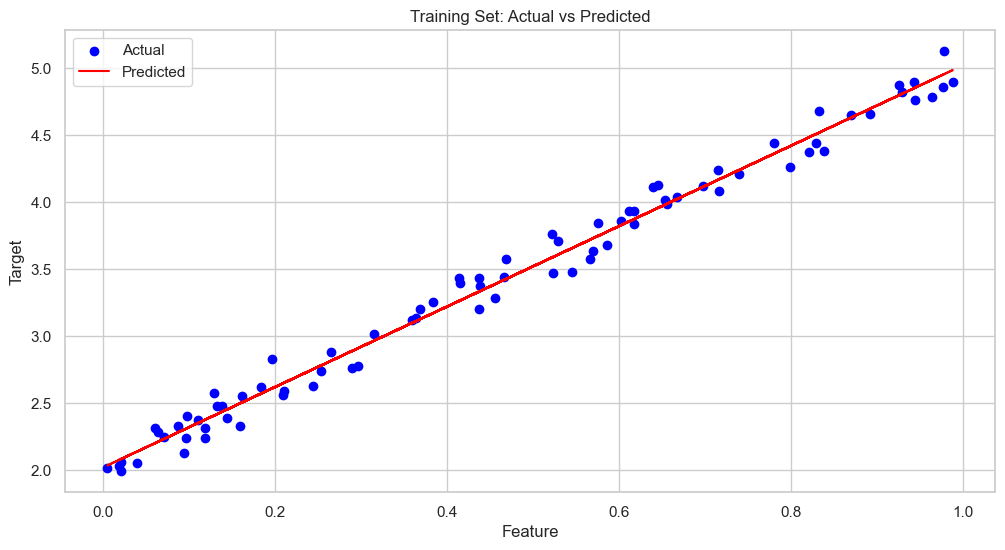

In [102]:
plt.figure(figsize=(12,6))

plt.scatter(features_train, targets_train, color = 'blue', label = 'Actual')
plt.plot(features_train, predictions_train, color = 'red', label = 'Predicted')
plt.title('Training Set: Actual vs Predicted') 
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()

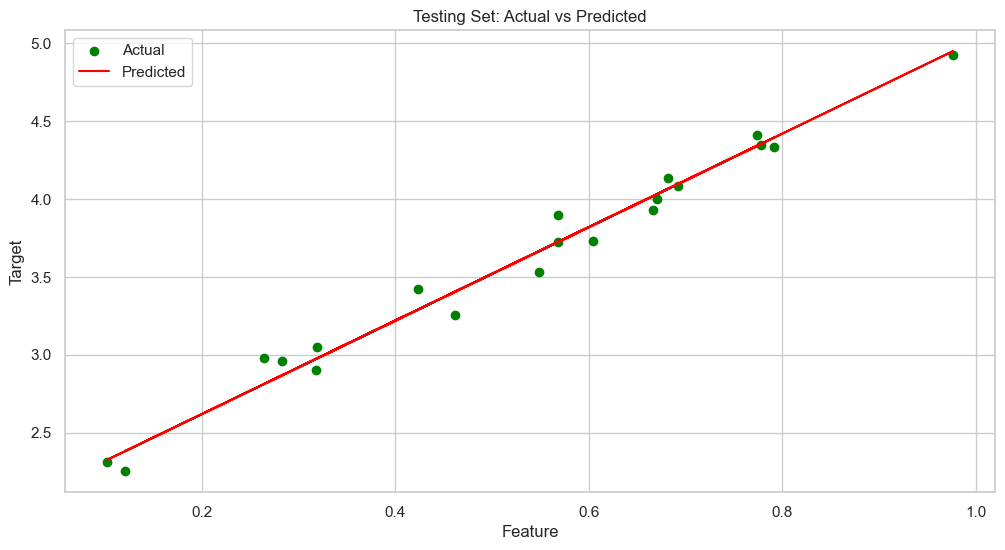

In [104]:
plt.figure(figsize=(12,6))

plt.scatter(features_test, targets_test, color = 'green', label = 'Actual')
plt.plot(features_test, predictions_test, color = 'red', label = 'Predicted')
plt.title('Testing Set: Actual vs Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()

In [98]:
print(f'Intercept: {model_lr.intercept_:.2f}')
print(f'Coefficient: {model_lr.coef_[0]:.2f}')

Intercept: 2.02
Coefficient: 3.00


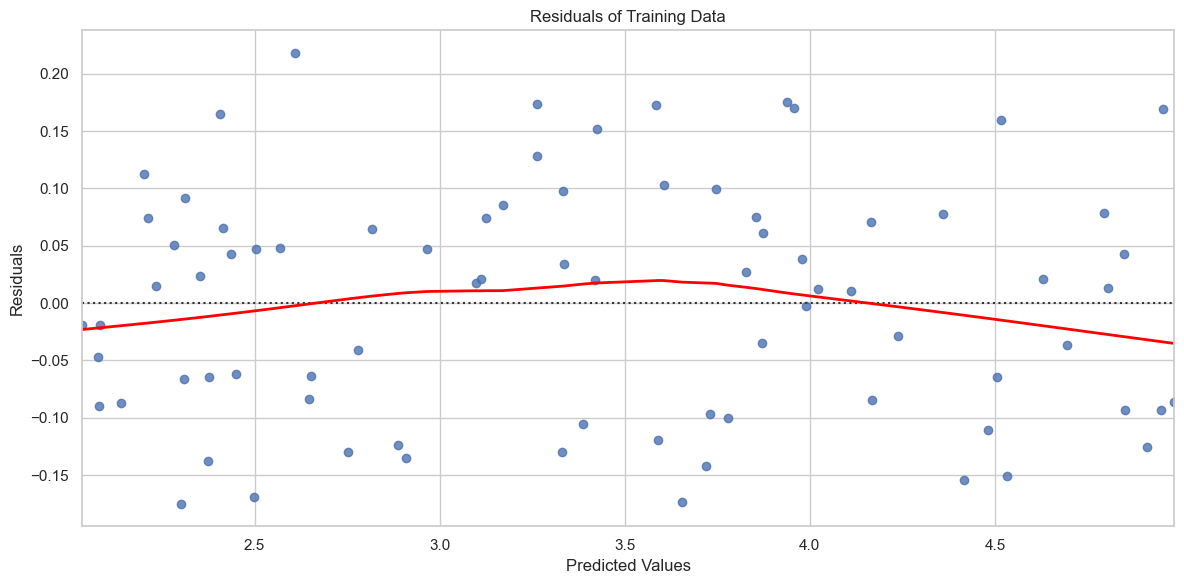

In [139]:
plt.figure(figsize = (12,6))
residuals_train = targets_train - predictions_train 
sns.residplot(x = predictions_train, y = residuals_train, lowess = True, line_kws = {'color': 'red', 'lw': 2})
plt.title('Residuals of Training Data')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

#### 2. Decision Tree Regression Model

In [113]:
dt_regressor = DecisionTreeRegressor (max_depth = 5, min_samples_leaf = 10, random_state = 42)

dt_regressor.fit(features_train, targets_train)

predictions_train_dt = dt_regressor.predict(features_train)
predictions_test_dt = dt_regressor.predict(features_test)

In [121]:
r2_train_dt = r2_score(targets_train, predictions_train_dt)
mse_train_dt = mean_squared_error(targets_train, predictions_train_dt)
r2_test_dt = r2_score(targets_test, predictions_test_dt)
mse_test_dt = mean_squared_error(targets_test, predictions_test_dt)

print(f'Decision Tree - Training Performance')
print(f'R-squared score for training set: {r2_train_dt:.2f}')
print(f'MSE for training set: {mse_train_dt:.2f}')

print(f'\nDecision Tree - Testing Performance')
print(f'R-squared score for testing set: {r2_test_dt:.2f}')
print(f'MSE for testing set: {mse_test_dt:.2f}')

Decision Tree - Training Performance
R-squared score for training set: 0.96
MSE for training set: 0.03

Decision Tree - Testing Performance
R-squared score for testing set: 0.90
MSE for testing set: 0.05


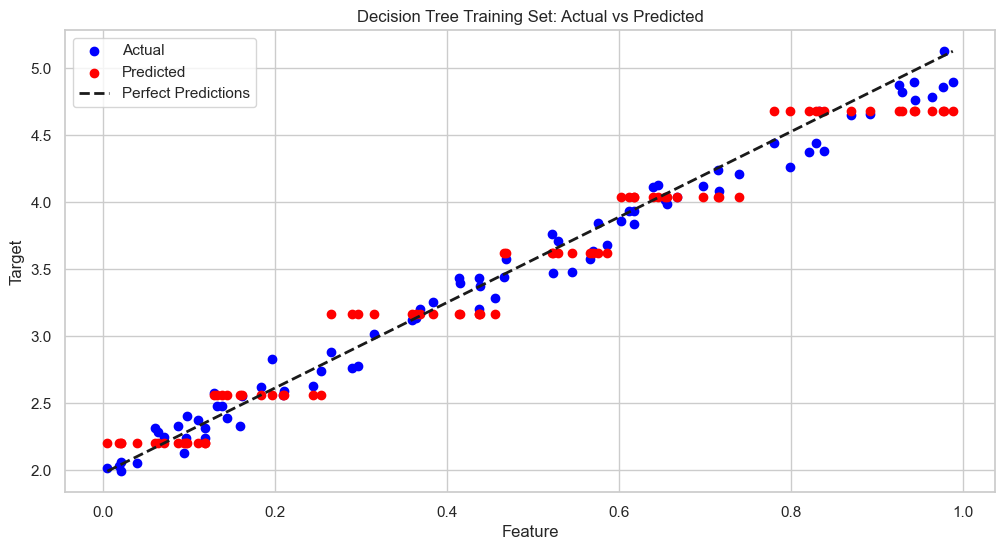

In [125]:
plt.figure(figsize = (12,6))

plt.scatter(features_train, targets_train, color = 'blue', label = 'Actual')
plt.scatter(features_train, predictions_train_dt, color = 'red', label = 'Predicted')
plt.plot([features_train.min(), features_train.max()],[targets_train.min(), targets_train.max()], 'k--', lw = 2, label = 'Perfect Predictions')
plt.title('Decision Tree Training Set: Actual vs Predicted') 
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

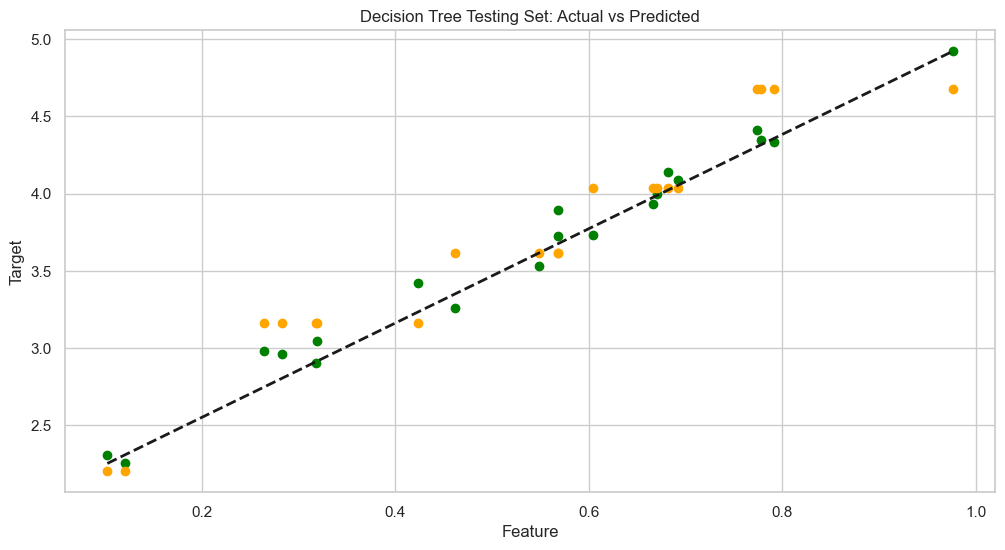

In [133]:
plt.figure(figsize = (12,6))

plt.scatter(features_test, targets_test, color = 'green', label = 'Actual')
plt.scatter(features_test, predictions_test_dt, color = 'orange', label = 'Predicted')

plt.plot([features_test.min(), features_test.max()], [targets_test.min(), targets_test.max()], 'k--', lw =2, label = 'Perfect Predictions')
plt.title('Decision Tree Testing Set: Actual vs Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend

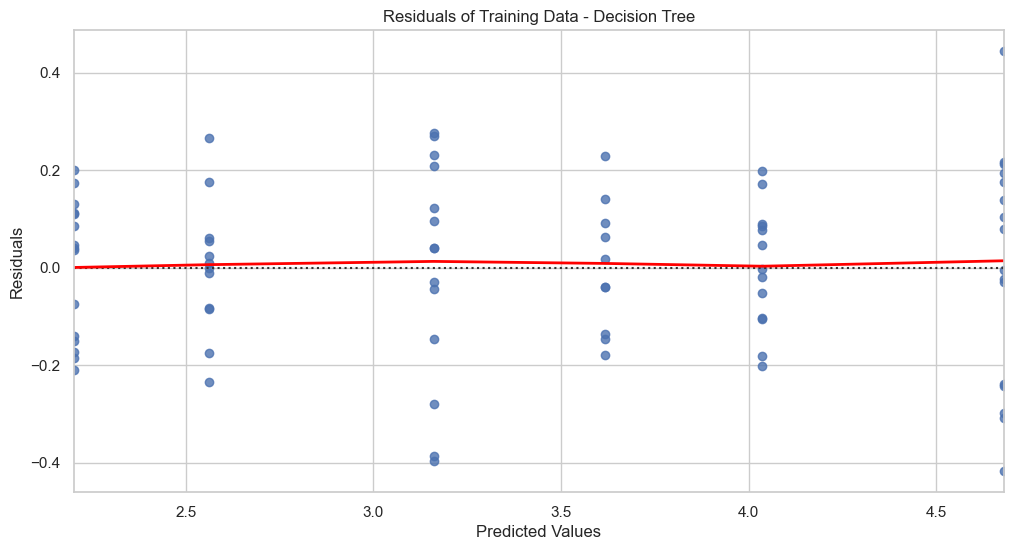

In [137]:
residuals_train_dt = targets_train - predictions_train_dt

plt.figure(figsize = (12,6))
sns.residplot(x = predictions_train_dt, y = residuals_train_dt, lowess = True, line_kws = {'color': 'red', 'lw':2})
plt.title('Residuals of Training Data - Decision Tree')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#### 3. Random Forest Regression Model

In [144]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42) 

rf.fit(features_train, targets_train)

predictions_train_rf = rf.predict(features_train)
predictions_test_rf = rf.predict(features_test)

In [146]:
r2_train_rf = r2_score(targets_train, predictions_train_rf)
mse_train_rf = mean_squared_error(targets_train, predictions_train_rf)
r2_test_rf = r2_score(targets_test, predictions_test_rf)
mse_test_rf = mean_squared_error(targets_test, predictions_test_rf)

print(f'Random Forest - Training Performance')
print(f'R-squared score for training set: {r2_train_rf:.2f}')
print(f'MSE for training set: {mse_train_rf:.2f}')

print(f'\nRandom Forest - Testing Performance')
print(f'R-squared score for testing set: {r2_test_rf:.2f}')
print(f'MSE for testing set: {mse_test_rf:.2f}')

Random Forest - Training Performance
R-squared score for training set: 1.00
MSE for training set: 0.00

Random Forest - Testing Performance
R-squared score for testing set: 0.98
MSE for testing set: 0.01


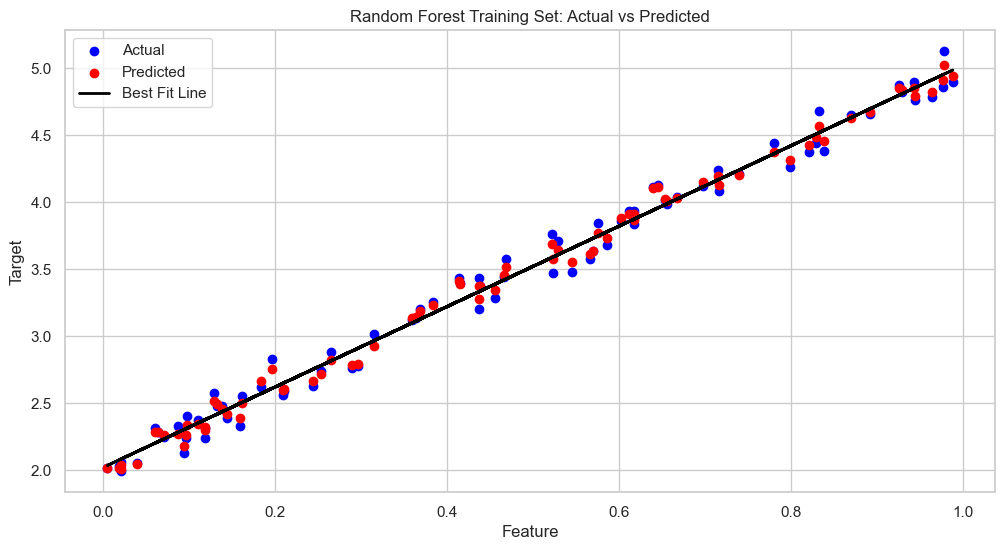

In [149]:
plt.figure(figsize=(12,6))

plt.scatter(features_train, targets_train, color = 'blue', label = 'Actual')
plt.scatter(features_train, predictions_train_rf, color = 'red', label = 'Predicted')

slope, intercept = np.polyfit(features_train.values.ravel(), targets_train.values.ravel(),1)
plt.plot(features_train, slope * features_train.values + intercept, color = 'black', linewidth = 2, label = 'Best Fit Line')
plt.title('Random Forest Training Set: Actual vs Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()


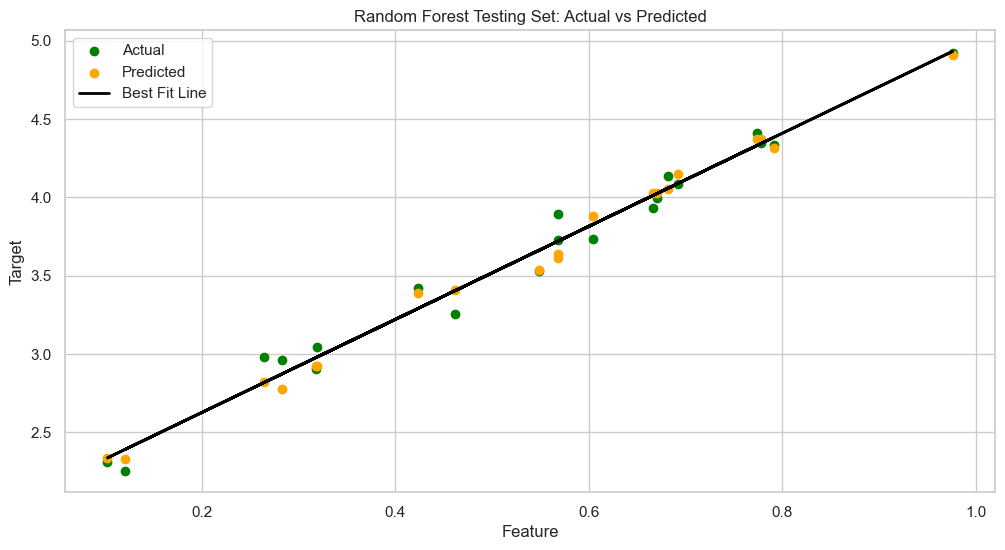

In [157]:
plt.figure(figsize = (12,6))

plt.scatter(features_test, targets_test, color = 'green', label = 'Actual')
plt.scatter(features_test, predictions_test_rf, color = 'orange', label = 'Predicted')
slope_test, intercept_test = np.polyfit(features_test.values.ravel(), targets_test.values.ravel(),1)
plt.plot(features_test, slope_test * features_test.values + intercept_test, color = 'black', linewidth = 2, label = 'Best Fit Line')
plt.title('Random Forest Testing Set: Actual vs Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

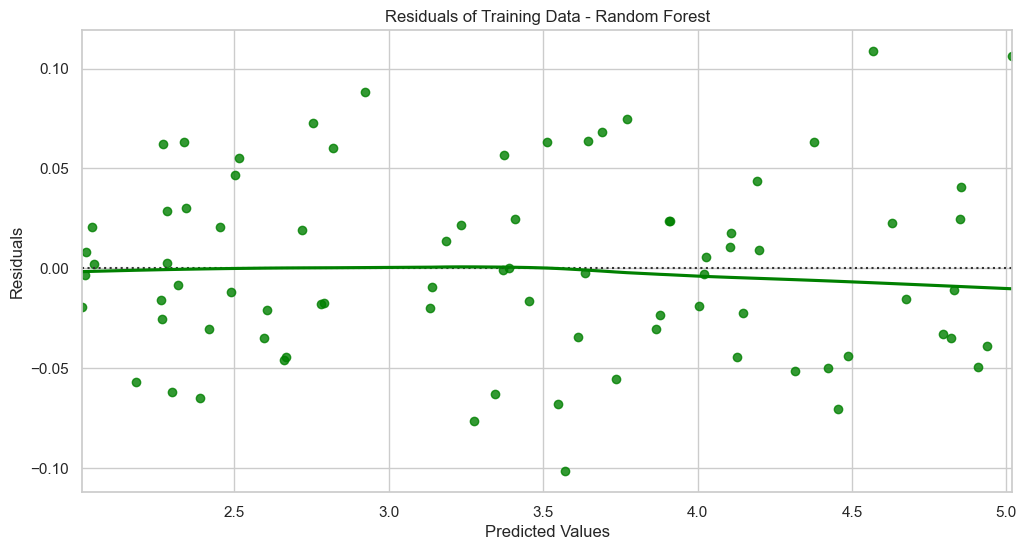

In [163]:
residuals_train_rf = targets_train - predictions_train_rf

plt.figure(figsize = (12,6))
sns.residplot(x = predictions_train_rf, y = residuals_train_rf, lowess = True, color = 'green')
plt.title('Residuals of Training Data - Random Forest')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

### Conclusion

* Random Forest Model generally outperforms others in terms of perfect $R^2$ score and low MSE on training set, indicating an almost exact fit to the training data. However, the drop in values from training to testing do suggest a slight overfitting.

* Linear Regression Model also performed very well, with a high $R^2$ score and low MSE. The close results from training and testing data suggests that the model is very stable and generalises well on unseen data. 